In [28]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity 


In [29]:
import pandas as pd
df = pd.read_csv("../data/processed/clean_data.csv")
df.head()

,title,tags_x,genre,popularity,vote_count,vote_average
0,my little pony: a new generation,"robert cullen, josé lui ucha vanessa hudgens, ...","Animation, Family, Fantasy, Comedy, Music, Adv...",137.815,190.0,popular
1,the starling,"theodor melfi melissa mccarthy, chri o'dowd, k...",Drama,27.515,174.0,popular
2,je suis karl,"christian schwochow luna wedler, janni niewöhn...",Drama,19.294,20.0,not_popular
3,confessions of an invisible girl,"bruno garotti klara castanho, lucca picon, júl...","Comedy, Drama",62.097,144.0,average
4,intrusion,"adam salki freida pinto, logan marshall-green,...",Thriller,60.475,412.0,below_avg


In [30]:
print(df.shape)
print(df.columns)

(1726, 6)
Index(['title', 'tags_x', 'genre', 'popularity', 'vote_count', 'vote_average'], dtype='str')


# create fake user 

In [31]:
np.random.seed(42)

num_users = 1000
num_movies  =df.shape[0]

# generate random rating

In [32]:
ratings_data = []

In [33]:
for user in range(num_users):

    watched_movies = np.random.choice(
        num_movies,
        size = 20
    )

    for movie in watched_movies:
        rating = np.random.randint(1,6)

        ratings_data.append(
            [user,movie,rating]
        )

In [34]:
ratings_df = pd.DataFrame(

    ratings_data,

    columns = [

        'user_Id',
        'movie_Id',
        'rating'
    ]
)

ratings_df.head()

,user_Id,movie_Id,rating
0,0,1126,5
1,0,1459,2
2,0,860,4
3,0,1294,2
4,0,1130,4


# create user_movie matrix

In [35]:
user_movie_matrix = ratings_df.pivot_table(
    index = 'user_Id',
    columns = 'movie_Id',
    values = 'rating'
)

In [36]:
user_movie_matrix.head()

movie_Id,0,1,2,3,4,5,6,7,8,9,...,1716,1717,1718,1719,1720,1721,1722,1723,1724,1725
user_Id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# fill missing values

In [37]:
user_movie_marix = user_movie_matrix.fillna(0)

In [38]:
user_movie_matrix = user_movie_matrix.fillna(0)

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(
    user_movie_matrix
)

In [40]:
print(user_similarity.shape)

(1000, 1000)


# recommendation function

In [41]:
def recommend_collabrative(user_id):

    similar_user = list(
        enumerate(
            user_similarity[user_id]
        )
    )

    similar_user= sorted(
        similar_user,
        reverse = True,
        key = lambda x:x[1]

    )[1:6]

    recommended_movies = set()

    for user,score in similar_user:

        movies = ratings_df[
            ratings_df['user_Id']==user

        ]['movie_Id']

        recommended_movies.update(
            movies
        )

        movie_names = df.iloc[
        list(recommended_movies)
        ].title.values

        return movie_names[:5]

# Test

In [42]:
recommend_collabrative(10)

<StringArray>
['sweeney todd: the demon barber of fleet street',
      'harold & kumar escape from guantanamo bay',
                              'your lie in april',
                          'the amityville horror',
              'charlie and the chocolate factory']
Length: 5, dtype: str

In [43]:
import pickle

pickle.dump(

    user_similarity,
    open("../models/user_similarity.pkl",
         "wb"
    )
)

# Visualize ratings distribution

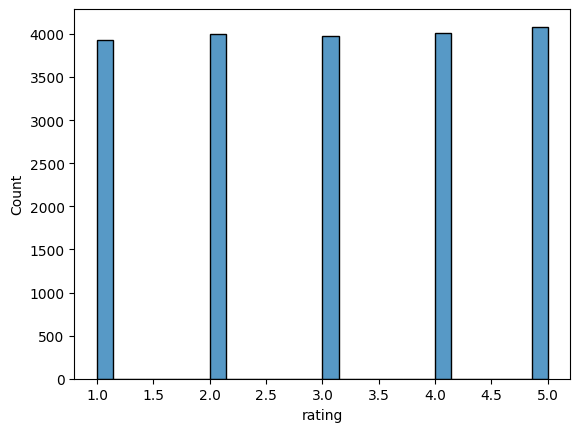

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    ratings_df['rating']
)
plt.show()

In [45]:
user_movie_matrix.shape

(1000, 1726)

In [46]:
user_movie_matrix.shape

(1000, 1726)

In [47]:
import pickle

with open("../Models/movies.pkl", "wb") as f:
    pickle.dump(movie, f)

with open("../Models/user_similarity.pkl", "wb") as f:
    pickle.dump(user_similarity, f)

with open("../Models/user_movie_matrix.pkl", "wb") as f:
    pickle.dump(user_movie_matrix, f)    

print("Files saved successfully!")

Files saved successfully!
